In [1]:
# =============================================================================
# BLOCK 1: IMPORTS
# =============================================================================
import numpy as np
import pandas as pd
import random
from scipy.integrate import solve_ivp
from google.colab import files
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import cumulative_trapezoid

In [2]:
files.upload()

Saving low.csv to low.csv
Saving medium.csv to medium.csv


{'low.csv': b'battery_id,cycle,voltage,temperature,capacity,soh,rul\r\nB0045,1,3.331115608931800,9.550861490886550,1.2130043500964800,1.0,71\r\nB0045,2,3.3261589009052200,9.501609704058560,1.0740903759179600,0.885479409725554,70\r\nB0045,3,3.347444081314830,9.182344431847840,1.0314016051548900,0.8502868147775890,69\r\nB0045,4,3.3477018391509900,9.12569338411823,1.0010659864614600,0.825278150389022,68\r\nB0045,5,3.350988890598850,9.129155713890890,0.9767009677502960,0.8051916447559440,67\r\nB0045,6,3.34909358990855,9.157107194704860,0.9570199680992920,0.7889666414000700,66\r\nB0045,7,3.335922927444350,9.333738109493910,0.9339034392674870,0.7699093900143130,65\r\nB0045,8,3.3538584351485600,9.406521645869530,0.9516974109686330,0.7845787287514180,64\r\nB0045,9,3.3601940345679300,9.332993108051260,0.934972870107539,0.7707910281056910,63\r\nB0045,10,3.3523314948664100,9.444905698491020,0.918238834582374,0.7569955000650590,62\r\nB0045,11,3.3690360375931100,9.426838378865620,0.9047160820536340

In [3]:
# =============================================================================
# BLOCK 2: PARAMETER DEFINITIONS
# =============================================================================

# --- Battery Specs ---
Q_r_0 = 14.8       # Wh — starting capacity of a brand-new battery.
                    # This is the anchor for the recursive degradation:
                    #     Q_r[0] = Q_r_0,  Q_r[n] = Q_r[n-1] * f_temp(T_n)

# --- Measured Power Ranges (W) ---
# Screen power: measured range across brightness levels
SCREEN_POWER_MIN  = 0.00642     # W (lowest brightness)
SCREEN_POWER_MAX  = 0.6642      # W (highest brightness)

# Processor power: averages ~1 W, able to spike up to ~10 W under heavy load averaging at 4 W
PROCESSOR_POWER_BASE = 1.0      # W (average, always running while screen is on)
PROCESSOR_POWER_OFFSET_MIN = -0.5   # W (can dip below average during light tasks)
PROCESSOR_POWER_OFFSET_MAX =  1.5   # W (can go above average)

# Network power: measured range
NETWORK_POWER_MIN = 0.05        # W (background / idle)
NETWORK_POWER_MAX = 0.60        # W (active data transfer)

# --- Idle Power ---
IDLE_ENERGY_PER_8H_Wh = 0.0555
P_IDLE = IDLE_ENERGY_PER_8H_Wh / 8.0  # W

# --- Initial Conditions ---
SOC_0 = random.uniform(0.70, 1.0)   # charge level at start (70–100%)
a_0 = 0             # number of prior cycles (0 = brand new battery)
T_ambient = 25      # C (ambient temperature)

# --- Simulation Parameters (Single Day) ---
t_start = 0         # hours
t_end = 24          # hours (simulate 1 full day)
num_points = 1000   # number of time points for output

# --- Multi-Cycle Simulation Parameters ---
total_cycles = 500          # simulate until 500 total cycles
degradation_threshold = 0.5 # stop when capacity drops below 50% of Q_r_0

In [4]:
# =============================================================================
# BLOCK 3: TIME-VARYING PLACEHOLDER FUNCTIONS
#          *** REPLACE THESE WITH YOUR REGRESSION MODELS ***
# =============================================================================

def z_t(t):
    """
    Screen usage indicator function.
    Returns 1 if screen is on (active use), 0 if screen is off (idle).

    Placeholder: simulates a typical daily pattern:
        - 6:00-7:00    Morning routine (checking phone)
        - 7:00-8:30    Commute (using phone)
        - 8:30-12:00   Work (phone idle)
        - 12:00-13:00  Lunch break (using phone)
        - 13:00-17:30  Work (phone idle)
        - 17:30-18:30  Commute (using phone)
        - 18:30-22:00  Evening / social media (using phone)
        - 22:00-6:00   Sleep (phone idle)
    """
    hour = t % 24  # cycle within a 24-hour day

    if 6.0 <= hour < 7.0:       # morning routine
        return 1
    elif 7.0 <= hour < 8.5:     # commute
        return 1
    elif 8.5 <= hour < 12.0:    # work
        return 0
    elif 12.0 <= hour < 13.0:   # lunch
        return 1
    elif 13.0 <= hour < 17.5:   # work
        return 0
    elif 17.5 <= hour < 18.5:   # commute
        return 1
    elif 18.5 <= hour < 22.0:   # evening / social media
        return 1
    else:                        # sleep
        return 0
def screen_power_t(t):
    """
    Screen power draw (W) at time t.
    Only draws power when z(t) = 1 (screen is on).
    Each call samples a random value in the measured range to simulate
    brightness variation during active use.

    Range: [SCREEN_POWER_MIN, SCREEN_POWER_MAX] = [0.00642, 0.6642] W
    """
    if z_t(t) == 0:
        return 0.0
    return random.uniform(SCREEN_POWER_MIN, SCREEN_POWER_MAX)


def processor_power_t(t):
    """
    Processor power draw (W) at time t.
    Only draws power when the phone is actively being used (z(t) = 1).
    A random offset is added to the base to simulate task variation:
        processor_power = PROCESSOR_POWER_BASE + random(-1, 6)
    This gives a range of 3–10 W during active use, with the distribution
    centered around 4 W (the measured average).

    When idle (z(t) = 0), returns 0 — background drain is handled by P_idle.
    """
    if z_t(t) == 0:
        return 0.0
    offset = random.uniform(PROCESSOR_POWER_OFFSET_MIN, PROCESSOR_POWER_OFFSET_MAX)
    return PROCESSOR_POWER_BASE + offset


def network_power_t(t):
    """
    Network power draw (W) at time t.
    Samples a random value in the measured range each call.
    Network is active whether screen is on or off (background updates).

    Range: [NETWORK_POWER_MIN, NETWORK_POWER_MAX] = [0.05, 0.6] W
    """
    return random.uniform(NETWORK_POWER_MIN, NETWORK_POWER_MAX)
def temperature_t(t):
    """
    Ambient/operating temperature as a function of time (C).

    Placeholder: simulates temperature variation over a day.
        - Night (0-6):     cool (18C)
        - Morning (6-10):  warming (22C)
        - Midday (10-16):  warm (28C)
        - Evening (16-22): cooling (24C)
        - Night (22-24):   cool (18C)

    TODO: Replace with your model (e.g., weather data, indoor vs. outdoor).
    """
    hour = t % 24

    if 0 <= hour < 6:
        return 18
    elif 6 <= hour < 10:
        return 22
    elif 10 <= hour < 16:
        return 28
    elif 16 <= hour < 22:
        return 24
    else:
        return 18

In [5]:
# =============================================================================
# BLOCK 4: DEGRADATION FUNCTIONS
#          Reads low.csv and medium.csv, computes cycle-to-cycle SOH ratios,
#          fits piecewise linear regressions (soh_ratio ~ temperature),
#          and defines f_temp using the fitted models.
#
#  Threshold: average of max(low temps) and min(medium temps)
#
#  Why ratios, not raw SOH?
#      The R regressions (soh ~ temperature) predict absolute SOH.
#      For the recursive update Q_r[n] = Q_r[n-1] * f_temp(T), we need
#      a per-cycle multiplier. So we derive:
#          soh_ratio[n] = soh[n] / soh[n-1]
#      and regress: soh_ratio ~ temperature
#      This gives a value < 1 that compounds correctly each cycle.
# =============================================================================

# --- File paths (update these if your CSVs move) ---
LOW_CSV_PATH    = "low.csv"
MEDIUM_CSV_PATH = "medium.csv"

# --- Load the data ---
low_df  = pd.read_csv(LOW_CSV_PATH)
med_df  = pd.read_csv(MEDIUM_CSV_PATH)

# --- Derive the temperature threshold from the data ---
# (average of the max temperature in low data and min temperature in medium data)
TEMP_THRESHOLD = (low_df['temperature'].max() + med_df['temperature'].min()) / 2
print(f"[Block 4] Temperature threshold: {TEMP_THRESHOLD:.4f} C")
print(f"          (max low = {low_df['temperature'].max():.4f}, min med = {med_df['temperature'].min():.4f})")


def _compute_soh_ratios(df):
    """
    For each battery in df, compute the cycle-to-cycle SOH ratio
    and pair it with that cycle's temperature.

        soh_ratio[n] = soh[n] / soh[n-1]

    Returns a DataFrame with columns: temperature, soh_ratio
    """
    rows = []
    for _, group in df.groupby('battery_id'):
        group = group.sort_values('cycle').reset_index(drop=True)
        for i in range(1, len(group)):
            prev_soh = group.loc[i - 1, 'soh']
            if prev_soh > 0:
                rows.append({
                    'temperature': group.loc[i, 'temperature'],
                    'soh_ratio':   group.loc[i, 'soh'] / prev_soh
                })
    return pd.DataFrame(rows)


# --- Compute ratios from each dataset ---
low_ratios = _compute_soh_ratios(low_df)
med_ratios = _compute_soh_ratios(med_df)

# --- Fit linear regressions: soh_ratio ~ temperature ---
low_reg = LinearRegression().fit(low_ratios[['temperature']], low_ratios['soh_ratio'])
med_reg = LinearRegression().fit(med_ratios[['temperature']], med_ratios['soh_ratio'])

print(f"[Block 4] Low  regression: ratio = {low_reg.intercept_:.6f} + {low_reg.coef_[0]:.6f} * T   (R² = {low_reg.score(low_ratios[['temperature']], low_ratios['soh_ratio']):.4f})")
print(f"[Block 4] High regression: ratio = {med_reg.intercept_:.6f} + {med_reg.coef_[0]:.6f} * T   (R² = {med_reg.score(med_ratios[['temperature']], med_ratios['soh_ratio']):.4f})")


def f_temp(T):
    """
    Piecewise temperature degradation factor (per-cycle multiplier).
    Uses the sklearn LinearRegression models fitted above on cycle-to-cycle
    SOH ratios from low.csv and medium.csv.

    If T < TEMP_THRESHOLD:  uses low_reg  (fitted on low.csv ratios)
    If T >= TEMP_THRESHOLD: uses med_reg  (fitted on medium.csv ratios)

    Used recursively each cycle:
        Q_r[n] = Q_r[n-1] * f_temp(T_n)

    Parameters:
        T : average temperature during the cycle (C)

    Returns:
        Multiplicative degradation factor for this cycle (typically < 1)
    """
    if T < TEMP_THRESHOLD:
        return float(low_reg.predict(pd.DataFrame([[T]], columns=['temperature']))[0])
    else:
        return float(med_reg.predict(pd.DataFrame([[T]], columns=['temperature']))[0])

[Block 4] Temperature threshold: 21.5224 C
          (max low = 13.2147, min med = 29.8301)
[Block 4] Low  regression: ratio = 0.979613 + 0.001708 * T   (R² = 0.0118)
[Block 4] High regression: ratio = 0.970255 + 0.000870 * T   (R² = 0.0022)


In [6]:
# =============================================================================
# BLOCK 5: CORE MODEL FUNCTIONS
# =============================================================================

def P_idle(a=None):
    return P_IDLE


def _sample_power_table(t_grid):
    """
    Pre-sample the three power functions onto a time grid.
    Each point gets one random draw — this table is what the ODE integrates
    against, so the randomness is fixed and smooth for the duration of one solve.

    Returns:
        (t_grid, screen_arr, processor_arr, network_arr)
    """
    screen_arr    = np.array([screen_power_t(t)    for t in t_grid])
    processor_arr = np.array([processor_power_t(t) for t in t_grid])
    network_arr   = np.array([network_power_t(t)   for t in t_grid])
    return screen_arr, processor_arr, network_arr

# Module-level table (overwritten before each solve)
_power_t_grid      = None
_power_screen      = None
_power_processor   = None
_power_network     = None

def PC(t):
    """
    Active power consumption (W) at time t.
    Looks up pre-sampled power values via linear interpolation.
    Call _sample_power_table() and set the module-level arrays before
    each solve_ivp call — do NOT call the random power functions directly
    inside the ODE.
    """
    screen    = float(np.interp(t, _power_t_grid, _power_screen))
    processor = float(np.interp(t, _power_t_grid, _power_processor))
    network   = float(np.interp(t, _power_t_grid, _power_network))
    return screen + processor + network
def Q_r_next(Q_r_prev, T):
    """
    Recursive battery capacity update.
    Each cycle, Q_r is multiplied by f_temp evaluated at that cycle's
    average temperature.

        Q_r[n] = Q_r[n-1] * f_temp(T_n)

    Parameters:
        Q_r_prev : capacity at the previous cycle (Wh)
        T        : average temperature during this cycle (C)

    Returns:
        Q_r[n] : updated capacity (Wh)
    """
    return Q_r_prev * f_temp(T)

In [7]:
# =============================================================================
# BLOCK 6: ODE SYSTEM
# =============================================================================

def dSOC_dt(t, SOC, current_Qr):
    """
    Main ODE: rate of change of State of Charge.

    dSOC/dt = -(PC(t) + P_idle(a)) / current_Qr

    Parameters:
        t          : time (hours)
        SOC        : current state of charge (0 to 1)
        current_Qr : battery capacity for this cycle (Wh), held constant
                     during one discharge and updated recursively between cycles

    Returns:
        dSOC/dt : rate of change of SOC (1/hour)
    """
    # Clamp SOC so it doesn't go below 0
    if SOC[0] <= 0:
        return [0.0]

    total_power = PC(t) + P_idle(current_cycle_for_idle)  # total power draw (W)
    derivative  = -total_power / current_Qr               # dSOC/dt (1/hour)

    return [derivative]

In [8]:
# =============================================================================
# BLOCK 7: SOLVE THE ODE — SINGLE DAY
# =============================================================================

# Compute Q_r at a_0 cycles by recursively applying f_temp from Q_r_0.
# Each cycle uses the average daily temperature as the representative T.
avg_daily_T = np.mean([temperature_t(t) for t in np.linspace(0, 24, 500)])
current_Qr_single = Q_r_0
for _ in range(a_0):
    current_Qr_single = Q_r_next(current_Qr_single, avg_daily_T)

print(f"[Single Day] Q_r after {a_0} cycles (avg T = {avg_daily_T:.2f} C): {current_Qr_single:.4f} Wh")

# Set global cycle count so dSOC_dt can access it for P_idle
current_cycle_for_idle = a_0

# Time span and evaluation points
t_span = (t_start, t_end)
t_eval = np.linspace(t_start, t_end, num_points)

# Initial condition: SOC(0) = SOC_0
y0 = [SOC_0]

# Pre-sample power onto the time grid — one random draw per point.
# The ODE will interpolate from this table; no random calls during integration.
_power_t_grid, _power_screen, _power_processor, _power_network = (
    t_eval,
    *_sample_power_table(t_eval)
)

# Solve using scipy's solve_ivp
# current_Qr_single is held constant during one discharge day
solution = solve_ivp(
    fun=lambda t, y: dSOC_dt(t, y, current_Qr_single),
    t_span=t_span,
    y0=y0,
    t_eval=t_eval,
    method='RK45',          # Runge-Kutta 4th/5th order
    max_step=0.01           # small step size for accuracy with piecewise z(t)
)

# Extract results
t_sol  = solution.t         # time points (hours)
SOC_sol = solution.y[0]     # SOC values (0 to 1)

# Clamp SOC to [0, 1]
SOC_sol = np.clip(SOC_sol, 0, 1)

# Find time-to-empty (when SOC first hits 0)
zero_indices = np.where(SOC_sol <= 0)[0]
if len(zero_indices) > 0:
    time_to_empty = t_sol[zero_indices[0]]
    print(f"[Single Day] Time to empty: {time_to_empty:.2f} hours")
else:
    time_to_empty = None
    print(f"[Single Day] Battery did not fully drain within {t_end} hours.")
    print(f"[Single Day] Final SOC: {SOC_sol[-1]*100:.2f}%")

[Single Day] Q_r after 0 cycles (avg T = 22.66 C): 14.8000 Wh
[Single Day] Time to empty: 13.09 hours


In [9]:
# =============================================================================
# BLOCK 8: MULTI-CYCLE SIMULATION
#
# Logic:
#   - Each cycle = one full day (24 hours)
#   - Phone charges overnight (22:00-6:00), SOC resets to 1.0 at start of each day
#   - Q_r updates recursively each cycle: Q_r[n] = Q_r[n-1] * f_temp(T_avg)
#   - 'a' (cycle count) increments by 1 each day (used only for P_idle)
#   - Simulation stops when Q_r drops below degradation_threshold * Q_r_0
# =============================================================================

multi_cycle_data = {
    'cycle_number':      [],     # which cycle (day)
    'time_to_empty':     [],     # hours until SOC hits 0 that day
    'effective_capacity':[],     # Q_r at start of that day (Wh)
    'f_temp_value':      [],     # f_temp(T_avg) applied that cycle
    'idle_power':        [],     # P_idle(a) that day (mW)
}

# Full trace arrays (for plotting SOC across all days continuously)
all_t_multi   = []   # time in hours (continuous across days)
all_SOC_multi = []   # SOC values

# Initialize Q_r recursively from Q_r_0 up to a_0 cycles
# (same warm-up as single-day, using avg daily temperature)
current_Qr = Q_r_0
for _ in range(a_0):
    current_Qr = Q_r_next(current_Qr, avg_daily_T)

current_cycle = a_0  # start at a_0 cycles
day_number    = 0    # which simulated day we're on

print("\n--- Multi-Cycle Simulation ---")
print(f"{'Cycle':<8} {'Capacity (Wh)':<16} {'f_temp':<10} {'Idle (mW)':<12} {'Time to Empty (h)'}")
print("-" * 70)

while current_cycle < total_cycles:
    # Check if battery is too degraded
    if current_Qr / Q_r_0 < degradation_threshold:
        print(f"\n[Multi-Cycle] Battery degraded below {degradation_threshold*100:.0f}% capacity at cycle {current_cycle}. Stopping.")
        break

    # Compute average temperature for this day (used for recursive Q_r update)
    day_t_eval = np.linspace(0, 24, 500)
    day_avg_T  = np.mean([temperature_t(t) for t in day_t_eval])
    day_ftemp  = f_temp(day_avg_T)

    # Set global cycle count for P_idle inside dSOC_dt
    current_cycle_for_idle = current_cycle

    # Pre-sample a fresh power table for this day
    _power_t_grid, _power_screen, _power_processor, _power_network = (
        day_t_eval,
        *_sample_power_table(day_t_eval)
    )

    # Solve one day (24 hours) with current Q_r held constant
    cycle_SOC_0 = random.uniform(0.70, 1.0)   # overnight charge is 70–100%
    day_solution = solve_ivp(
        fun=lambda t, y, qr=current_Qr: dSOC_dt(t, y, qr),
        t_span=(0, 24),
        y0=[cycle_SOC_0],
        t_eval=day_t_eval,
        method='RK45',
        max_step=0.01
    )

    day_t   = day_solution.t
    day_SOC = np.clip(day_solution.y[0], 0, 1)

    # Find time to empty for this day
    zero_idx = np.where(day_SOC <= 0)[0]
    if len(zero_idx) > 0:
        day_tte = day_t[zero_idx[0]]
    else:
        day_tte = None  # didn't fully drain

    # Store full trace (shift time by day_number * 24 for continuous plot)
    time_offset = day_number * 24
    all_t_multi.append(day_t + time_offset)
    all_SOC_multi.append(day_SOC)

    # Store summary data
    multi_cycle_data['cycle_number'].append(current_cycle)
    multi_cycle_data['time_to_empty'].append(day_tte)
    multi_cycle_data['effective_capacity'].append(current_Qr)
    multi_cycle_data['f_temp_value'].append(day_ftemp)
    multi_cycle_data['idle_power'].append(P_idle(current_cycle) * 1000)  # convert to mW

    # Print every 50 cycles
    if day_number % 50 == 0:
        tte_str = f"{day_tte:.2f}" if day_tte else "24.00+"
        print(f"{current_cycle:<8} {current_Qr:<16.4f} {day_ftemp:<10.6f} {P_idle(current_cycle)*1000:<12.2f} {tte_str}")

    # --- Recursive update: Q_r for next cycle ---
    current_Qr = Q_r_next(current_Qr, day_avg_T)

    # Increment cycle and day
    current_cycle += 1
    day_number += 1

# Concatenate multi-cycle trace arrays
if len(all_t_multi) > 0:
    all_t_multi   = np.concatenate(all_t_multi)
    all_SOC_multi = np.concatenate(all_SOC_multi)
else:
    all_t_multi   = np.array([])
    all_SOC_multi = np.array([])

# Convert summary lists to arrays
cycles_arr       = np.array(multi_cycle_data['cycle_number'])
tte_arr          = np.array([x if x is not None else 24.0 for x in multi_cycle_data['time_to_empty']])
capacity_arr     = np.array(multi_cycle_data['effective_capacity'])
f_temp_arr       = np.array(multi_cycle_data['f_temp_value'])
idle_power_arr   = np.array(multi_cycle_data['idle_power'])

print(f"\n[Multi-Cycle] Simulated {day_number} days ({current_cycle - a_0} cycles).")
print(f"[Multi-Cycle] Final effective capacity: {capacity_arr[-1]:.2f} Wh ({capacity_arr[-1]/Q_r_0*100:.1f}% of original)")
print(f"[Multi-Cycle] Final time to empty: {tte_arr[-1]:.2f} hours")


--- Multi-Cycle Simulation ---
Cycle    Capacity (Wh)    f_temp     Idle (mW)    Time to Empty (h)
----------------------------------------------------------------------
0        14.8000          0.989979   6.94         17.84
50       8.9444           0.989979   6.94         9.47

[Multi-Cycle] Battery degraded below 50% capacity at cycle 69. Stopping.

[Multi-Cycle] Simulated 69 days (69 cycles).
[Multi-Cycle] Final effective capacity: 7.46 Wh (50.4% of original)
[Multi-Cycle] Final time to empty: 7.84 hours


=== Depletion diagnostics ===
Capacity (Wh): 14.8000
Depletion time (SOC hits 0): 13.093093093093094
Max |energy_integral - energy_from_SOC| up to depletion: 0.261007 Wh


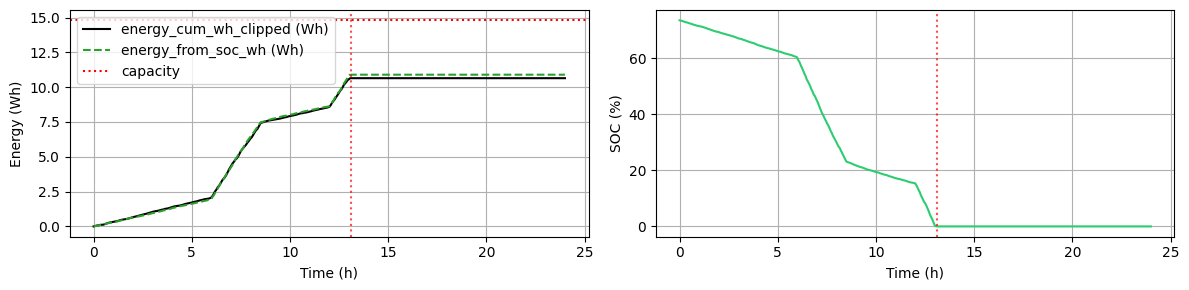

In [12]:
# =============================================================================
# BLOCK 9: COMPUTE INTERMEDIATE VARIABLES FOR SINGLE-DAY PLOTTING
# =============================================================================


# Precompute all time-varying quantities at each time point.
# Power arrays are interpolated from the pre-sampled table that the ODE
# integrated against — this keeps plots and summary consistent with the SOC curve.
z_vals               = np.array([z_t(t)           for t in t_sol])
temperature_vals     = np.array([temperature_t(t) for t in t_sol])
screen_power_vals    = np.interp(t_sol, _power_t_grid, _power_screen)
processor_power_vals = np.interp(t_sol, _power_t_grid, _power_processor)
network_power_vals   = np.interp(t_sol, _power_t_grid, _power_network)

idle_power_val       = P_idle(a_0)  # constant for the day (always-on)
total_power_vals     = screen_power_vals + processor_power_vals + network_power_vals + idle_power_val

# -------------------------------------------------------------------------
# Cumulative energy consumed (Wh) — integrate power over time
# Use trapezoidal integration on the solver time base to stay consistent.
# -------------------------------------------------------------------------
energy_cum_wh = np.concatenate(([0.0], cumulative_trapezoid(total_power_vals, t_sol)))  # Wh

# -------------------------------------------------------------------------
# Authoritative depletion time: when SOC hits 0
# (Because the model clamps SOC at 0 and stops discharging after that.)
# -------------------------------------------------------------------------
zero_indices = np.where(SOC_sol <= 0)[0]
if len(zero_indices) > 0:
    soc_zero_idx = int(zero_indices[0])
    depletion_time = float(t_sol[soc_zero_idx])
else:
    soc_zero_idx = None
    depletion_time = None

# Clip cumulative energy after depletion so it doesn't keep increasing
energy_cum_wh_clipped = energy_cum_wh.copy()
if soc_zero_idx is not None:
    energy_cum_wh_clipped[soc_zero_idx:] = energy_cum_wh_clipped[soc_zero_idx]

# Energy implied by SOC change (should match energy_cum_wh_clipped closely up to depletion)
energy_from_soc_wh = (SOC_0 - SOC_sol) * current_Qr_single  # Wh

# Battery capacity over time (constant for single day)
Qr_vals = np.full_like(t_sol, current_Qr_single)

# -------------------------------------------------------------------------
# OPTIONAL: diagnostic plot (keep while debugging; remove later)
# -------------------------------------------------------------------------
print("=== Depletion diagnostics ===")
print(f"Capacity (Wh): {current_Qr_single:.4f}")
print(f"Depletion time (SOC hits 0): {depletion_time}")

# Compare energy curves up to depletion (or full day if not depleted)
end_idx = soc_zero_idx if soc_zero_idx is not None else len(t_sol) - 1
max_diff = np.max(np.abs(energy_cum_wh_clipped[:end_idx+1] - energy_from_soc_wh[:end_idx+1]))
print(f"Max |energy_integral - energy_from_SOC| up to depletion: {max_diff:.6f} Wh")

# --- Color Palette ---
color_SOC       = '#2ecc71'
color_z         = '#3498db'
color_screen    = '#e74c3c'
color_processor = '#9b59b6'
color_network   = '#f39c12'
color_idle      = '#1abc9c'
color_temp      = '#e67e22'
color_capacity  = '#34495e'

# If you want a quick visual:
figd, axd = plt.subplots(1, 2, figsize=(12, 3))

ax = axd[0]
ax.plot(t_sol, energy_cum_wh_clipped, label='energy_cum_wh_clipped (Wh)', color='black')
ax.plot(t_sol, energy_from_soc_wh, label='energy_from_soc_wh (Wh)', color='tab:green', linestyle='--')
ax.axhline(current_Qr_single, color='red', linestyle=':', label='capacity')
if depletion_time is not None:
    ax.axvline(depletion_time, color='red', linestyle=':', alpha=0.7)
ax.set_xlabel('Time (h)')
ax.set_ylabel('Energy (Wh)')
ax.legend()
ax.grid(True)

ax2 = axd[1]
ax2.plot(t_sol, SOC_sol * 100, color=color_SOC)
if depletion_time is not None:
    ax2.axvline(depletion_time, color='red', linestyle=':', alpha=0.7)
ax2.set_xlabel('Time (h)')
ax2.set_ylabel('SOC (%)')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Activity labels for annotation
activities = [
    (0, 6, 'Sleep'),
    (6, 7, 'Morning'),
    (7, 8.5, 'Commute'),
    (8.5, 12, 'Work'),
    (12, 13, 'Lunch'),
    (13, 17.5, 'Work'),
    (17.5, 18.5, 'Commute'),
    (18.5, 22, 'Evening'),
    (22, 24, 'Sleep'),
]




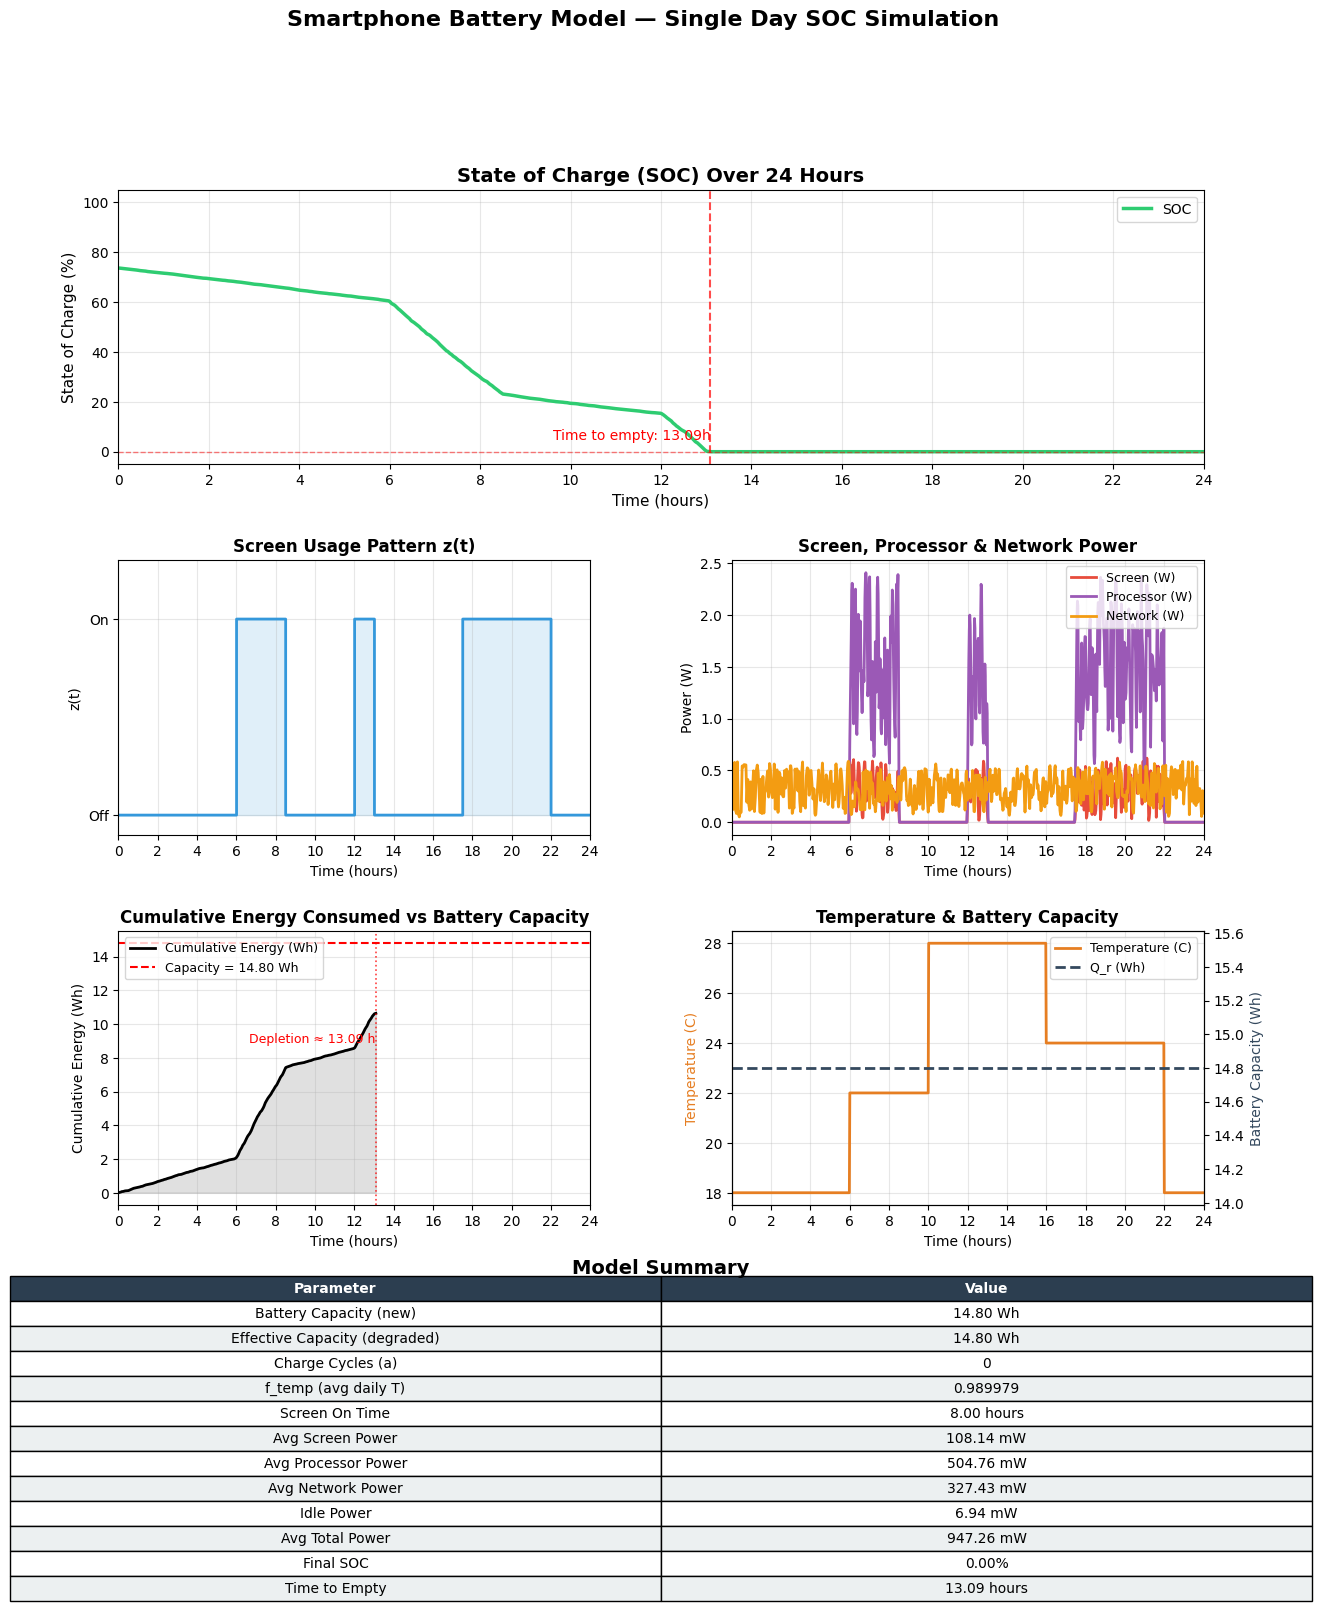

In [13]:
# =============================================================================
# BLOCK 10: VISUALIZATION — ORIGINAL DASHBOARD (kept as-is)
# =============================================================================

fig = plt.figure(figsize=(14, 18))
gs = gridspec.GridSpec(4, 2, hspace=0.35, wspace=0.3)


# ---------------------------------------------------------------------------
# Plot 1: SOC over time (main result)
# ---------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t_sol, SOC_sol * 100, color=color_SOC, linewidth=2.5, label='SOC')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
if time_to_empty:
    ax1.axvline(x=time_to_empty, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax1.annotate(f'Time to empty: {time_to_empty:.2f}h',
                 xy=(time_to_empty, 5), fontsize=10, color='red',
                 ha='right' if time_to_empty > 12 else 'left')
ax1.set_xlabel('Time (hours)', fontsize=11)
ax1.set_ylabel('State of Charge (%)', fontsize=11)
ax1.set_title('State of Charge (SOC) Over 24 Hours', fontsize=14, fontweight='bold')
ax1.set_xlim(t_start, t_end)
ax1.set_ylim(-5, 105)
ax1.set_xticks(range(0, 25, 2))
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# ---------------------------------------------------------------------------
# Plot 2: z(t) — Screen Usage Pattern
# ---------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[1, 0])
ax2.step(t_sol, z_vals, color=color_z, linewidth=2, where='post')
ax2.fill_between(t_sol, z_vals, alpha=0.15, color=color_z, step='post')
ax2.set_xlabel('Time (hours)', fontsize=10)
ax2.set_ylabel('z(t)', fontsize=10)
ax2.set_title('Screen Usage Pattern z(t)', fontsize=12, fontweight='bold')
ax2.set_xlim(t_start, t_end)
ax2.set_ylim(-0.1, 1.3)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Off', 'On'])
ax2.set_xticks(range(0, 25, 2))
ax2.grid(True, alpha=0.3)

# ---------------------------------------------------------------------------
# Plot 3: Screen, Processor & Network Power
# ---------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(t_sol, screen_power_vals, color=color_screen, linewidth=2, label='Screen (W)')
ax3.plot(t_sol, processor_power_vals, color=color_processor, linewidth=2, label='Processor (W)')
ax3.plot(t_sol, network_power_vals, color=color_network, linewidth=2, label='Network (W)')
ax3.set_xlabel('Time (hours)', fontsize=10)
ax3.set_ylabel('Power (W)', fontsize=10)
ax3.set_title('Screen, Processor & Network Power', fontsize=12, fontweight='bold')
ax3.set_xlim(t_start, t_end)
ax3.set_xticks(range(0, 25, 2))
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3)

# ---------------------------------------------------------------------------
# Plot 4: Cumulative Energy Consumed (Wh) vs Capacity
# ---------------------------------------------------------------------------
ax4 = fig.add_subplot(gs[2, 0])

# Use SOC-based depletion_time from Block 9 to crop for display (optional but clean)
if depletion_time is not None:
    mask = t_sol <= depletion_time
    t_plot = t_sol[mask]
    e_plot = energy_cum_wh_clipped[mask]
else:
    t_plot = t_sol
    e_plot = energy_cum_wh_clipped

# Plot cumulative energy
ax4.plot(t_plot, e_plot, color='black', linewidth=2.0, label='Cumulative Energy (Wh)')
ax4.fill_between(t_plot, 0, e_plot, alpha=0.12, color='black')

# Capacity line (use the same capacity the ODE used that day)
cap_wh = current_Qr_single
ax4.axhline(y=cap_wh, color='red', linestyle='--', linewidth=1.5, label=f'Capacity = {cap_wh:.2f} Wh')

# Depletion marker (same as SOC)
if depletion_time is not None:
    ax4.axvline(x=depletion_time, color='red', linestyle=':', linewidth=1.2, alpha=0.75)
    ax4.annotate(f'Depletion ≈ {depletion_time:.2f} h',
                 xy=(depletion_time, cap_wh * 0.6),
                 color='red', fontsize=9, ha='right')

ax4.set_xlabel('Time (hours)', fontsize=10)
ax4.set_ylabel('Cumulative Energy (Wh)', fontsize=10)
ax4.set_title('Cumulative Energy Consumed vs Battery Capacity', fontsize=12, fontweight='bold')
ax4.set_xlim(t_start, t_end)
ax4.set_xticks(range(0, 25, 2))
ax4.grid(True, alpha=0.3)
ax4.legend(loc='upper left', fontsize=9)


# ---------------------------------------------------------------------------
# Plot 5: Temperature and Battery Capacity
# ---------------------------------------------------------------------------
ax5 = fig.add_subplot(gs[2, 1])
ax5_twin = ax5.twinx()

ax5.plot(t_sol, temperature_vals, color=color_temp, linewidth=2, label='Temperature (C)')
ax5_twin.plot(t_sol, Qr_vals, color=color_capacity, linewidth=2, linestyle='--', label='Q_r (Wh)')

ax5.set_xlabel('Time (hours)', fontsize=10)
ax5.set_ylabel('Temperature (C)', fontsize=10, color=color_temp)
ax5_twin.set_ylabel('Battery Capacity (Wh)', fontsize=10, color=color_capacity)
ax5.set_title('Temperature & Battery Capacity', fontsize=12, fontweight='bold')
ax5.set_xlim(t_start, t_end)
ax5.set_xticks(range(0, 25, 2))

lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5_twin.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
ax5.grid(True, alpha=0.3)

# ---------------------------------------------------------------------------
# Plot 6: Summary Table
# ---------------------------------------------------------------------------
ax6 = fig.add_subplot(gs[3, :])
ax6.axis('off')

avg_screen_power    = np.mean(screen_power_vals)
avg_processor_power = np.mean(processor_power_vals)
avg_network_power   = np.mean(network_power_vals)
avg_total_power     = np.mean(total_power_vals)
total_active_hours  = np.sum(z_vals) * (t_sol[1] - t_sol[0])
final_SOC           = SOC_sol[-1] * 100
capacity_at_end     = current_Qr_single

table_data = [
    ['Battery Capacity (new)',        f'{Q_r_0:.2f} Wh'],
    ['Effective Capacity (degraded)', f'{capacity_at_end:.2f} Wh'],
    ['Charge Cycles (a)',             f'{a_0}'],
    ['f_temp (avg daily T)',          f'{f_temp(avg_daily_T):.6f}'],
    ['Screen On Time',                f'{total_active_hours:.2f} hours'],
    ['Avg Screen Power',              f'{avg_screen_power*1000:.2f} mW'],
    ['Avg Processor Power',           f'{avg_processor_power*1000:.2f} mW'],
    ['Avg Network Power',             f'{avg_network_power*1000:.2f} mW'],
    ['Idle Power',                    f'{idle_power_val*1000:.2f} mW'],
    ['Avg Total Power',               f'{avg_total_power*1000:.2f} mW'],
    ['Final SOC',                     f'{final_SOC:.2f}%'],
    ['Time to Empty',                 f'{time_to_empty:.2f} hours' if time_to_empty else 'Did not drain'],
]

table = ax6.table(
    cellText=table_data,
    colLabels=['Parameter', 'Value'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

for j in range(2):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(table_data) + 1):
    color = '#ecf0f1' if i % 2 == 0 else '#ffffff'
    for j in range(2):
        table[i, j].set_facecolor(color)

ax6.set_title('Model Summary', fontsize=14, fontweight='bold', pad=20)

plt.suptitle('Smartphone Battery Model — Single Day SOC Simulation', fontsize=16, fontweight='bold', y=0.98)
plt.savefig('battery_model_single_day.png', dpi=150, bbox_inches='tight')
plt.show()

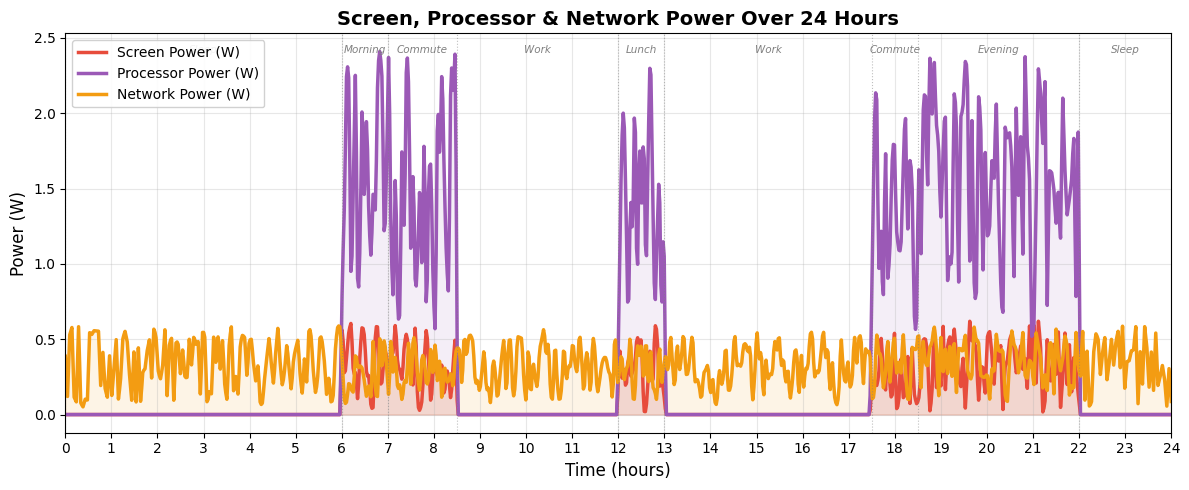

In [14]:
# =============================================================================
# BLOCK 11: VISUALIZATION — SEPARATE GRAPH: Screen, Processor & Network Power
# =============================================================================

fig_bp, ax_bp = plt.subplots(figsize=(12, 5))

ax_bp.plot(t_sol, screen_power_vals, color=color_screen, linewidth=2.5, label='Screen Power (W)')
ax_bp.fill_between(t_sol, screen_power_vals, alpha=0.1, color=color_screen)

ax_bp.plot(t_sol, processor_power_vals, color=color_processor, linewidth=2.5, label='Processor Power (W)')
ax_bp.fill_between(t_sol, processor_power_vals, alpha=0.1, color=color_processor)

ax_bp.plot(t_sol, network_power_vals, color=color_network, linewidth=2.5, label='Network Power (W)')
ax_bp.fill_between(t_sol, network_power_vals, alpha=0.1, color=color_network)

# Annotate activity periods along x-axis
for (start, end, label) in activities:
    mid = (start + end) / 2
    ax_bp.axvline(x=start, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax_bp.text(mid, ax_bp.get_ylim()[1] * 0.97, label, ha='center', va='top', fontsize=7.5, color='gray', style='italic')

ax_bp.set_xlabel('Time (hours)', fontsize=12)
ax_bp.set_ylabel('Power (W)', fontsize=12)
ax_bp.set_title('Screen, Processor & Network Power Over 24 Hours', fontsize=14, fontweight='bold')
ax_bp.set_xlim(0, 24)
ax_bp.set_xticks(range(0, 25, 1))
ax_bp.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax_bp.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('battery_model_brightness_processor_network.png', dpi=150, bbox_inches='tight')
plt.show()

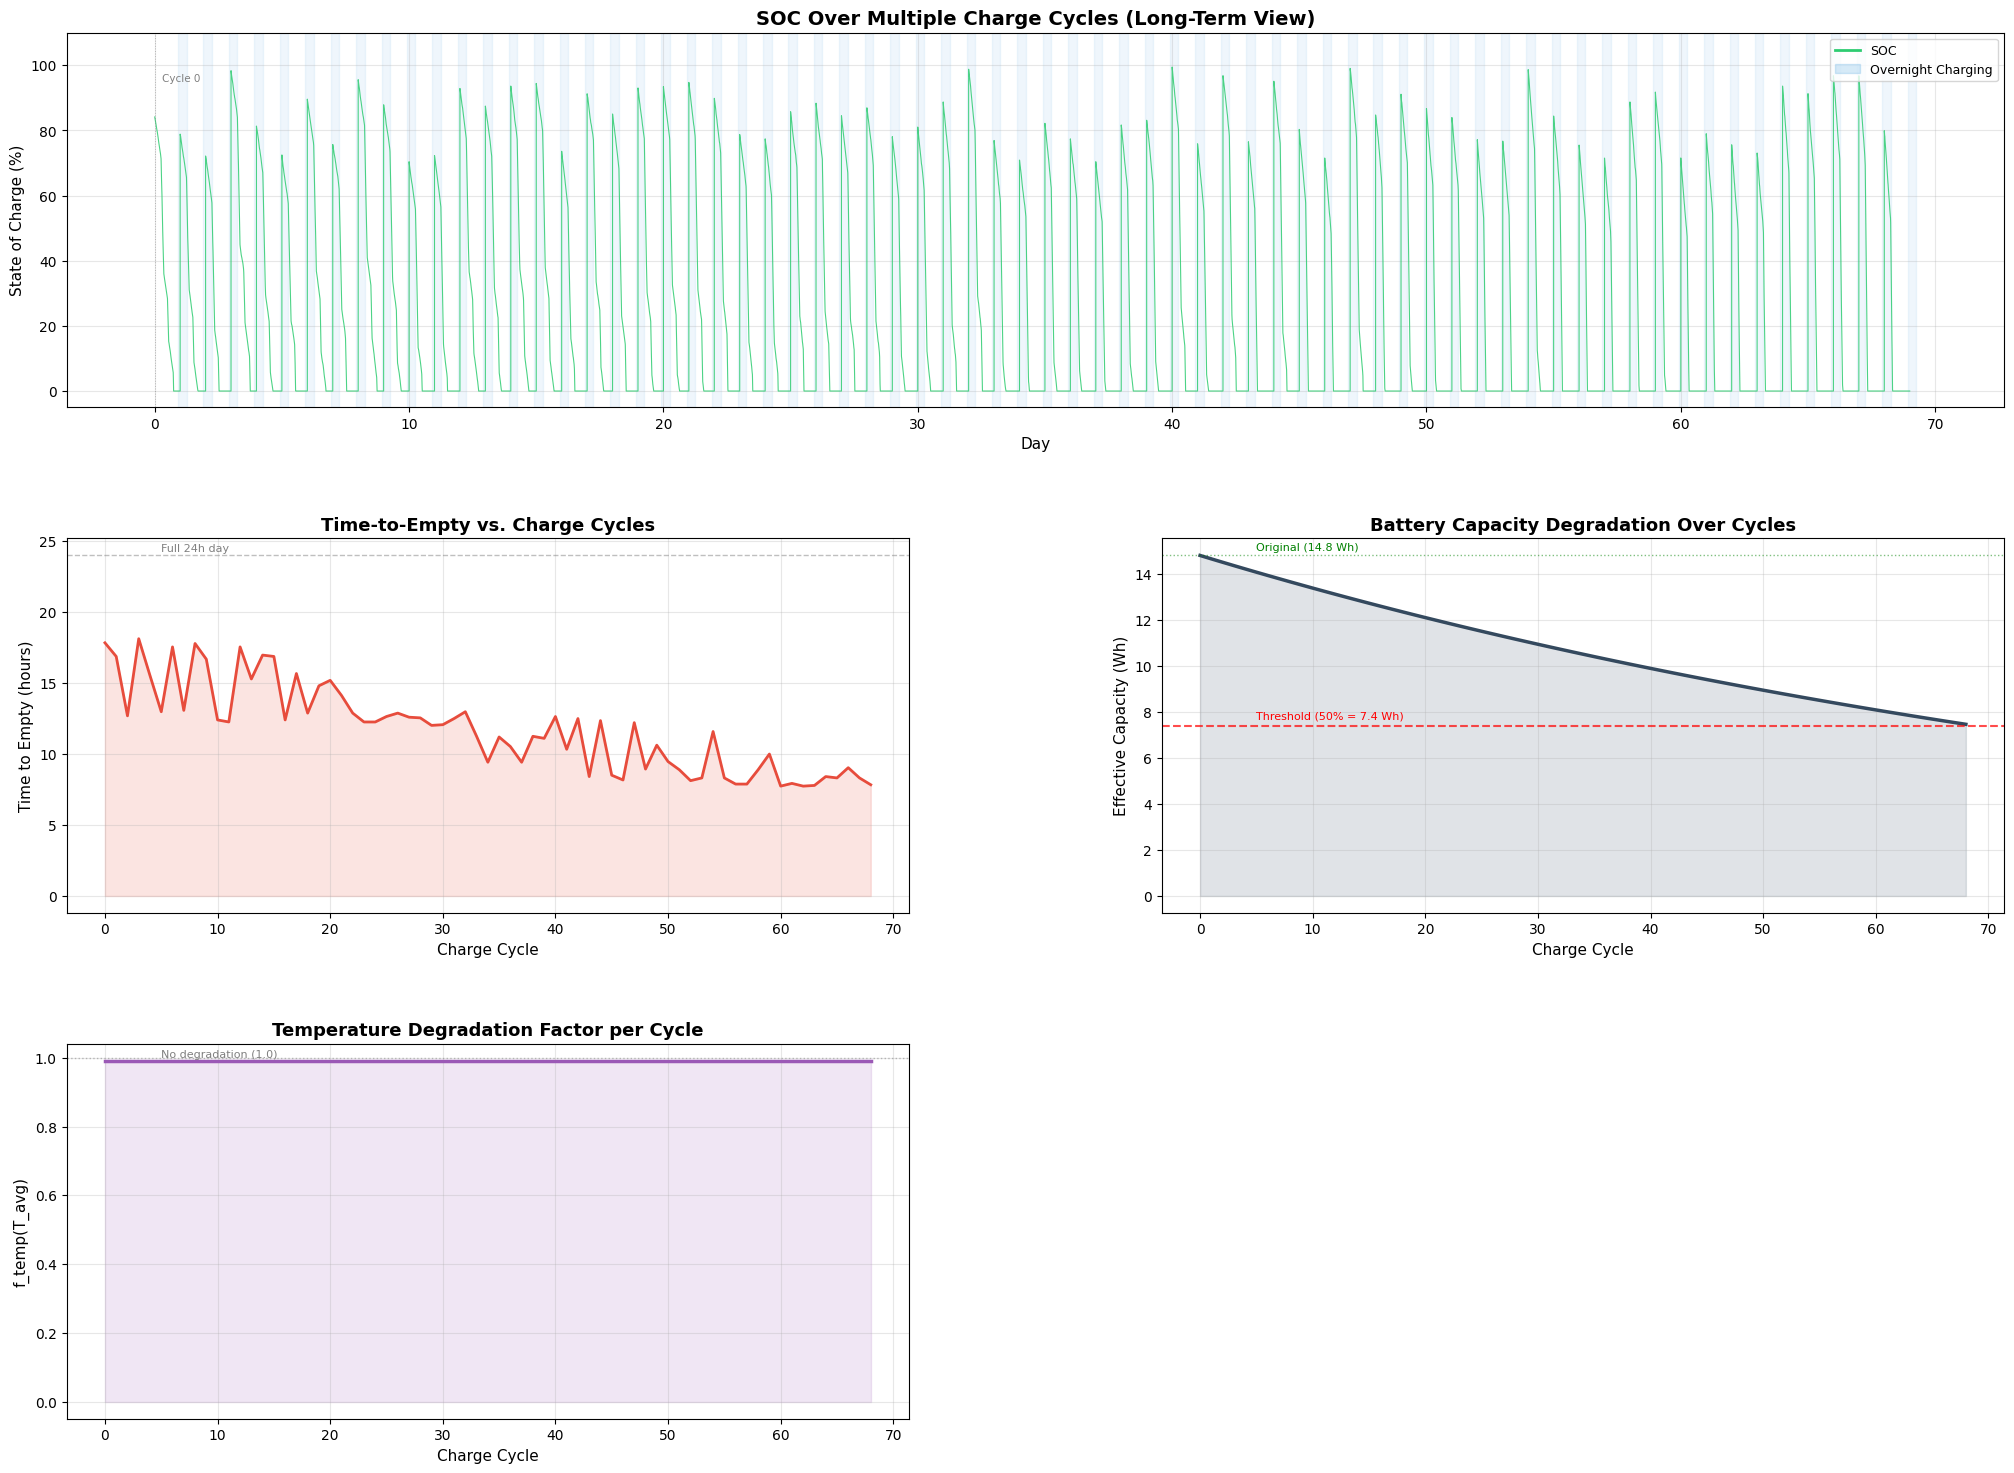

In [17]:
# =============================================================================
# BLOCK 13: VISUALIZATION — MULTI-CYCLE LONG-TERM SIMULATION
# =============================================================================

fig_multi = plt.figure(figsize=(25, 18))
gs_multi  = gridspec.GridSpec(3, 2, hspace=0.35, wspace=0.3)

# ---------------------------------------------------------------------------
# Plot 1 (top, full width): SOC across all simulated days
# ---------------------------------------------------------------------------
ax_m1 = fig_multi.add_subplot(gs_multi[0, :])

# Convert continuous time to days for x-axis
all_t_days = all_t_multi / 24.0

ax_m1.plot(all_t_days, all_SOC_multi * 100, color=color_SOC, linewidth=0.8, alpha=0.85)

# Shade overnight charging periods (22:00-6:00 each day)
num_days_simulated = day_number
for d in range(num_days_simulated):
    charge_start = d + 22/24
    charge_end   = d + 1 + 6/24
    ax_m1.axvspan(charge_start, charge_end, color='#3498db', alpha=0.08)

# Mark a few key cycles with vertical lines
key_cycles_to_mark = [a_0, a_0+100, a_0+200, a_0+300, a_0+400]
for kc in key_cycles_to_mark:
    day_idx = kc - a_0
    if day_idx < num_days_simulated:
        ax_m1.axvline(x=day_idx, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
        ax_m1.text(day_idx + 0.3, 95, f'Cycle {kc}', fontsize=7.5, color='gray', rotation=0)

ax_m1.set_xlabel('Day', fontsize=11)
ax_m1.set_ylabel('State of Charge (%)', fontsize=11)
ax_m1.set_title('SOC Over Multiple Charge Cycles (Long-Term View)', fontsize=14, fontweight='bold')
ax_m1.set_ylim(-5, 110)
ax_m1.legend(handles=[
                 plt.Line2D([0], [0], color=color_SOC, linewidth=2, label='SOC'),
                 plt.Rectangle((0,0), 1, 1, color='#3498db', alpha=0.2, label='Overnight Charging')
             ], loc='upper right', fontsize=9)
ax_m1.grid(True, alpha=0.3)

# ---------------------------------------------------------------------------
# Plot 2: Time-to-Empty per Cycle
# ---------------------------------------------------------------------------
ax_m2 = fig_multi.add_subplot(gs_multi[1, 0])

ax_m2.plot(cycles_arr, tte_arr, color='#e74c3c', linewidth=2)
ax_m2.fill_between(cycles_arr, tte_arr, alpha=0.15, color='#e74c3c')
ax_m2.axhline(y=24, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax_m2.text(cycles_arr[0] + 5, 24.3, 'Full 24h day', fontsize=8, color='gray')

ax_m2.set_xlabel('Charge Cycle', fontsize=11)
ax_m2.set_ylabel('Time to Empty (hours)', fontsize=11)
ax_m2.set_title('Time-to-Empty vs. Charge Cycles', fontsize=13, fontweight='bold')
ax_m2.grid(True, alpha=0.3)

# ---------------------------------------------------------------------------
# Plot 3: Effective Battery Capacity over Cycles
# ---------------------------------------------------------------------------
ax_m3 = fig_multi.add_subplot(gs_multi[1, 1])

ax_m3.plot(cycles_arr, capacity_arr, color=color_capacity, linewidth=2.5)
ax_m3.fill_between(cycles_arr, capacity_arr, alpha=0.15, color=color_capacity)

# Mark the degradation threshold
threshold_wh = Q_r_0 * degradation_threshold
ax_m3.axhline(y=threshold_wh, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax_m3.text(cycles_arr[0] + 5, threshold_wh + 0.3, f'Threshold ({degradation_threshold*100:.0f}% = {threshold_wh:.1f} Wh)',
           fontsize=8, color='red')

# Mark original capacity
ax_m3.axhline(y=Q_r_0, color='green', linestyle=':', linewidth=1, alpha=0.5)
ax_m3.text(cycles_arr[0] + 5, Q_r_0 + 0.2, f'Original ({Q_r_0} Wh)', fontsize=8, color='green')

ax_m3.set_xlabel('Charge Cycle', fontsize=11)
ax_m3.set_ylabel('Effective Capacity (Wh)', fontsize=11)
ax_m3.set_title('Battery Capacity Degradation Over Cycles', fontsize=13, fontweight='bold')
ax_m3.grid(True, alpha=0.3)


